In [1]:
const PROJECT_ROOT = joinpath(homedir(), "work", "Deborah.jl")
function localpath(relpath::AbstractString)
    return joinpath(PROJECT_ROOT, relpath)
end
# Base.invokelatest(include, localpath("src/Deborah.jl"))
# import .Deborah
using Revise
import Deborah.Rebekah; flush(stdout); flush(stderr)
import Deborah.RebekahMiriam;  flush(stdout); flush(stderr)

┌ Info: lib_lightgbm found in system dirs!
└ @ LightGBM /Users/benjamin/.julia/packages/LightGBM/xQZ0z/src/LightGBM.jl:32


In [12]:
# SAVE_DIR="SAVE_results_LBP1-10"
# SAVE_DIR="SAVE_results_LBP5-50"
SAVE_DIR="."
ns="12"
nt="4"
beta="1.60"
# model="TrM1-TrM1_BAS_TrM1-TrM2_GBM_TrM1-TrM3_GBM_TrM1-TrM4_GBM"
# model="TrM1-TrM1_BAS_TrM1-TrM2_RGM_TrM1-TrM3_RGM_TrM1-TrM4_RGM"
# model="TrM1-TrM1_BAS_TrM1-TrM2_LAS_TrM1-TrM3_LAS_TrM1-TrM4_LAS"
# model="TrM1-TrM1_BAS_TrM1-TrM2_RID_TrM1-TrM3_RID_TrM1-TrM4_RID"
model="Plaq-Rect-TrM1_GBM_Plaq-Rect-TrM2_GBM_Plaq-Rect-TrM3_GBM_Plaq-Rect-TrM4_GBM"


"Plaq-Rect-TrM1_GBM_Plaq-Rect-TrM2_GBM_Plaq-Rect-TrM3_GBM_Plaq-Rect-TrM4_GBM"

In [13]:
overall_name="L$(ns)T$(nt)b$(beta)_$(model)"

# --- Load result ---
result = Rebekah.JLD2Loader.load_jld2_Miriam(localpath("$(SAVE_DIR)/results_$(overall_name).jld2"))

rw_data = result.rw_data
new_dict = result.summary
labels = result.labels
trains = result.trains

Rebekah.PyPlotLaTeX.set_pyplot_latex_style()

In [14]:
second_block_keys_doc = [:kappa_t, :cond, :susp, :skew, :kurt, :bind]
keys_tex_doc = ["\$\\kappa_t\$", "\$\\Sigma\$", "\$\\chi\$", "\$S\$", "\$K\$",  "\$B\$"]

pred_tags = [:RWP1, :RWP2]
orig_tag = :RWBS

interpolation_criterion = ["susp", "skew", "kurt"]
interpolation_tex = ["\$\\chi\$", "\$S\$", "\$K\$"]

save_flag=true

key=:kurt
interpolate="kurt"
label="15"
train="20"


"20"

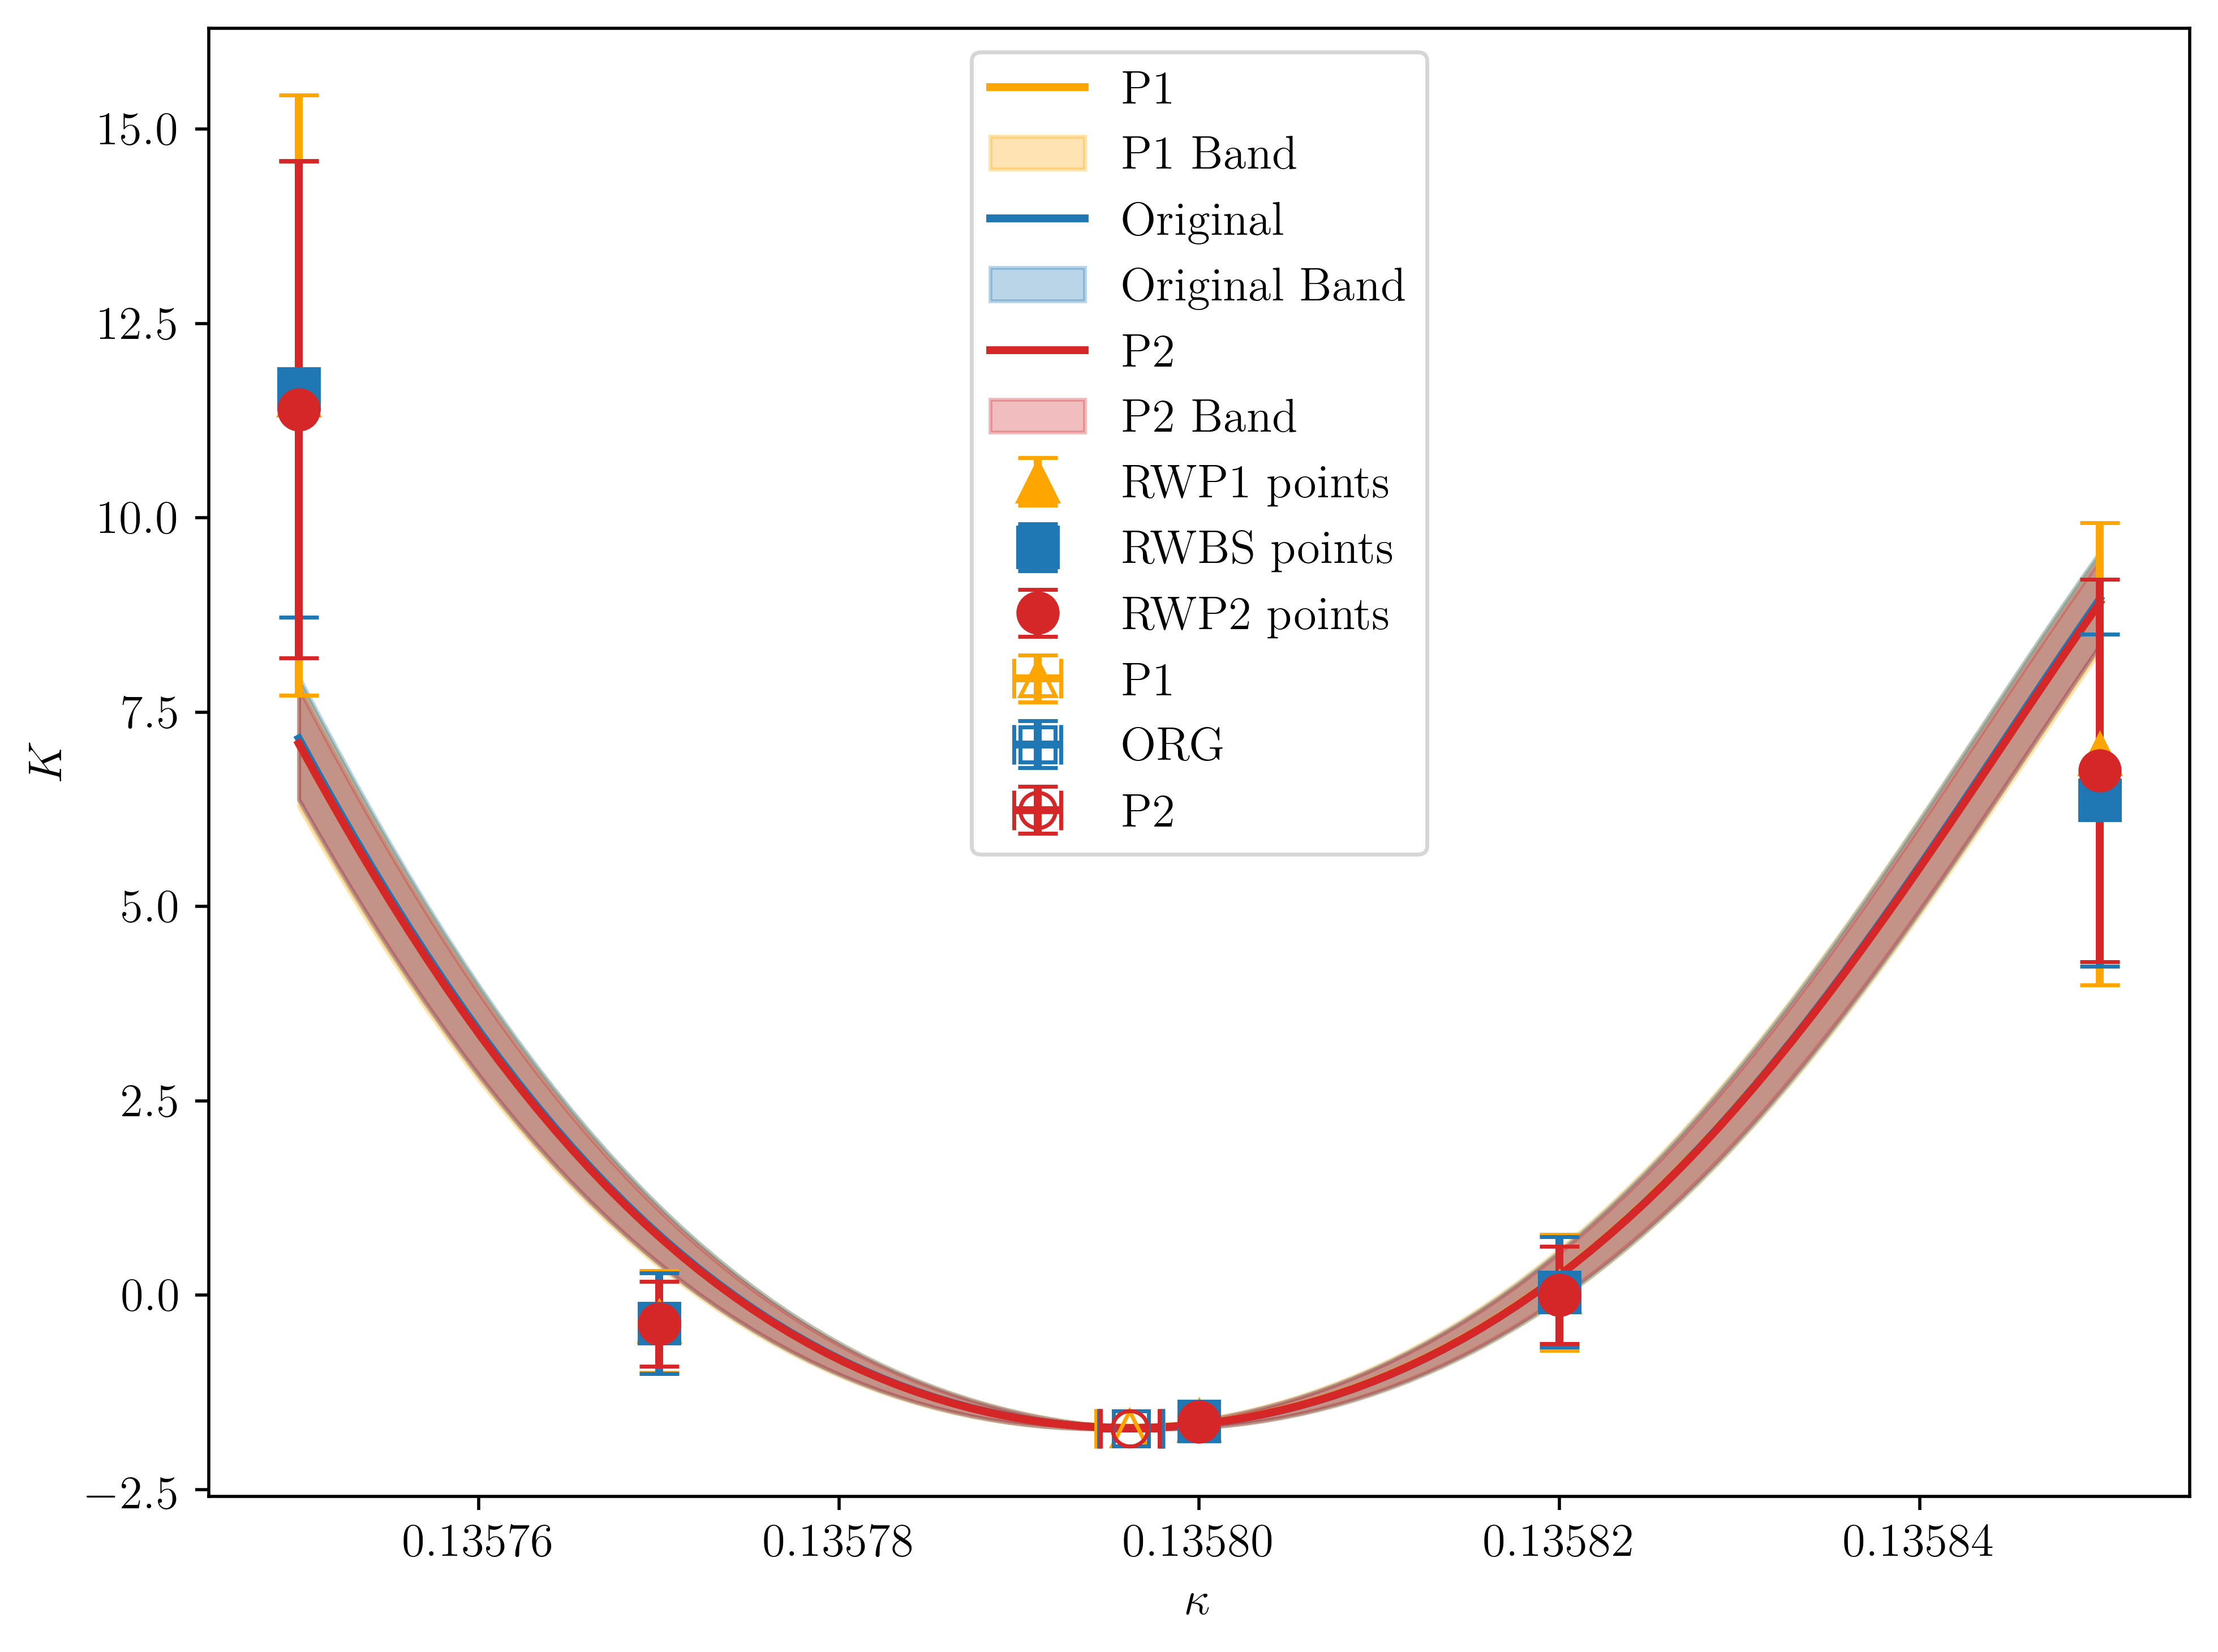

PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `/Users/benjamin/work/Deborah.jl/plot_kurt_kurt_L12T4b1.60_Plaq-Rect-TrM1_GBM_Plaq-Rect-TrM2_GBM_Plaq-Rect-TrM3_GBM_Plaq-Rect-TrM4_GBM-crop.pdf'.


In [15]:
RebekahMiriam.ReweightingPlotRebekahMiriam.plot_reweighting_pyplot(
    rw_data, 
    new_dict, 
    key, 
    keys_tex_doc[findfirst(==(key), second_block_keys_doc)], 
    label,
    train,
    labels, 
    trains, 
    interpolate,
	overall_name,
	PROJECT_ROOT;
	save_file=save_flag
)